# Memory Systems in Agentic AI

**How agents remember, forget, retrieve, and learn from experience**

---

## Memory Taxonomy

```
                        AGENT MEMORY
                            │
            ┌───────────────┼───────────────┐
            │               │               │
      SHORT-TERM       LONG-TERM       TEMPORARY
      (in-session)     (persisted)     (scoped)
            │               │               │
     ┌──────┤        ┌──────┼──────┐        │
     │      │        │      │      │        │
  Sensory Working  Episodic Semantic Procedural
  Buffer  Memory   Memory   Memory   Memory
```

| Memory Type | Human Analogy | Agent Equivalent | Lifespan |
|-------------|--------------|------------------|----------|
| **Sensory Buffer** | Glancing at a page | Current context window / token buffer | Milliseconds (one call) |
| **Working Memory** | Holding a phone number in your head | Scratchpad, conversation buffer | One session / graph run |
| **Episodic Memory** | Remembering your first day at work | Past interaction logs, conversation history | Permanent (stored) |
| **Semantic Memory** | Knowing that Paris is in France | Knowledge base, facts, user preferences | Permanent (stored) |
| **Procedural Memory** | Knowing how to ride a bike | Learned tools, prompt templates, skills | Permanent (stored) |
| **Temporary Memory** | Sticky note you throw away after use | Task-scoped state, cache, TTL-based | Scoped / expires |

---
## Setup

In [2]:
!pip install -q langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.2 MB/s eta 0:00:00


In [5]:
# --- Install required packages (run once in Colab) ---
!pip install -q langchain-google-genai langgraph python-dotenv seaborn

# --- Imports ---
import os, json, time, operator, hashlib, textwrap
from datetime import datetime, timedelta
from typing import TypedDict, Annotated, Any
from dataclasses import dataclass, field, asdict
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

from google.colab import userdata

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

sns.set_theme(style="darkgrid")

# --- Get API Key from Colab Secrets ---
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found in Colab secrets")

# --- Initialize LLM ---
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key=GEMINI_API_KEY,
    temperature=0.7,
)

def get_llm(temperature=0.7):
    return ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        google_api_key=GEMINI_API_KEY,
        temperature=temperature,
    )

# --- Test Call ---
resp = llm.invoke("Reply with: MEMORY SYSTEMS READY")
print(f" {resp.content}")

 MEMORY SYSTEMS READY


---
# 1. Sensory Buffer Memory

### In Plain English
When you glance at a page and immediately look away, you remember it for about 1 second. That's sensory memory — raw input that vanishes almost instantly.

### In Agents
The **context window** of the LLM is the sensory buffer. Whatever tokens fit in the window are "visible" to the model. Once the window is full, old tokens fall off. The model has zero awareness of anything outside this window.

**Key problem:** Context windows are finite (e.g., 1M tokens for Gemini). You can't just dump everything in.

In [6]:
# ── 1. Sensory Buffer — The Context Window ─────────────────────────────────
# Demonstrates: the model only "sees" what's in the current prompt.
# Anything not passed in = doesn't exist for the model.

class SensoryBuffer:
    """
    Simulates the LLM's context window as a fixed-size buffer.
    New tokens push old tokens out — just like real context windows.
    """
    def __init__(self, max_chars: int = 500):
        self.max_chars = max_chars
        self.buffer = ""

    def write(self, text: str):
        self.buffer += text
        # Trim from the front if over capacity (oldest tokens fall off)
        if len(self.buffer) > self.max_chars:
            dropped = len(self.buffer) - self.max_chars
            self.buffer = self.buffer[dropped:]
            return dropped
        return 0

    def read(self) -> str:
        return self.buffer

    def clear(self):
        self.buffer = ""

# Demo: watch tokens fall off
buf = SensoryBuffer(max_chars=200)

messages = [
    "The secret password is BLUE_ELEPHANT_42. Remember this.",
    "Now let's talk about something else. The weather is nice today.",
    "Machine learning models learn patterns from data. They use gradient descent.",
    "Neural networks have layers. Each layer transforms the input.",
]

print('SENSORY BUFFER DEMO (max 200 chars)')
print('='*55)

for i, msg in enumerate(messages):
    dropped = buf.write(msg + " ")
    print(f'\nMessage {i+1}: "{msg}"')
    print(f'  Chars dropped: {dropped}')
    print(f'  Buffer [{len(buf.read())} chars]: "{buf.read()[-80:]}..."')

# The password is now gone from the buffer!
print(f'\nDoes buffer still contain the password?')
print(f'  "BLUE_ELEPHANT_42" in buffer: {"BLUE_ELEPHANT_42" in buf.read()}')
print(f'\n Just like an LLM context window — old info gets pushed out.')
print('   The model has NO idea the password ever existed.')

SENSORY BUFFER DEMO (max 200 chars)

Message 1: "The secret password is BLUE_ELEPHANT_42. Remember this."
  Chars dropped: 0
  Buffer [56 chars]: "The secret password is BLUE_ELEPHANT_42. Remember this. ..."

Message 2: "Now let's talk about something else. The weather is nice today."
  Chars dropped: 0
  Buffer [120 chars]: " Remember this. Now let's talk about something else. The weather is nice today. ..."

Message 3: "Machine learning models learn patterns from data. They use gradient descent."
  Chars dropped: 0
  Buffer [197 chars]: "y. Machine learning models learn patterns from data. They use gradient descent. ..."

Message 4: "Neural networks have layers. Each layer transforms the input."
  Chars dropped: 59
  Buffer [200 chars]: "gradient descent. Neural networks have layers. Each layer transforms the input. ..."

Does buffer still contain the password?
  "BLUE_ELEPHANT_42" in buffer: False

 Just like an LLM context window — old info gets pushed out.
   The model has NO idea

---
# 2. Working Memory (Short-Term / Scratchpad)

### In Plain English
When you hold a phone number in your head while walking to write it down — that's working memory. It's temporary, limited, and disappears when you stop focusing.

### In Agents
Working memory is the **scratchpad** — a list that accumulates during one graph run. Nodes append thoughts, observations, intermediate results. It lives only for the duration of the task.

**Two flavors:**
- **Conversation buffer** — recent N messages of the chat
- **Scratchpad** — intermediate reasoning steps within one task

In [7]:
# ── 2A. Conversation Buffer Memory ──────────────────────────────────────────
# Keeps the last N messages. Older messages are forgotten.
# This is the simplest and most common agent memory.

class ConversationBufferMemory:
    """
    Sliding window of recent messages.
    When the buffer is full, oldest messages are evicted.
    """
    def __init__(self, max_messages: int = 6):
        self.max_messages = max_messages
        self.messages: deque = deque(maxlen=max_messages)

    def add(self, role: str, content: str):
        self.messages.append({'role': role, 'content': content, 'timestamp': datetime.now().isoformat()})

    def get_context(self) -> str:
        return '\n'.join(f"[{m['role']}]: {m['content']}" for m in self.messages)

    def __len__(self):
        return len(self.messages)

    def __repr__(self):
        return f'ConversationBuffer({len(self)}/{self.max_messages} messages)'


conv_mem = ConversationBufferMemory(max_messages=4)

exchanges = [
    ('user', 'My name is Sonu.'),
    ('assistant', 'Nice to meet you, Sonu!'),
    ('user', 'I work on AI agents.'),
    ('assistant', 'Interesting! What kind of agents?'),
    ('user', 'Multi-agent systems with alignment.'),
    ('assistant', 'Alignment is crucial for safe AI.'),
    ('user', 'What is my name?'),  # Will the agent still know?
]

print('CONVERSATION BUFFER MEMORY (max 4 messages)')
print('='*55)

for role, content in exchanges:
    conv_mem.add(role, content)
    print(f'\n Added: [{role}] "{content}"')
    print(f'   Buffer: {conv_mem}')
    print(f'   Current context:')
    for m in conv_mem.messages:
        print(f'     [{m["role"]}]: {m["content"]}')

# Ask the LLM using only what's in the buffer
context = conv_mem.get_context()
resp = llm.invoke(f'Conversation so far:\n{context}\n\nThe user asked: What is my name? Answer based ONLY on the conversation above.')

print(f'\n Agent response: {resp.content}')
print(f'\n The name "Sonu" was said in message 1, but the buffer only holds the last 4.')
print(f'   Message 1 was evicted → the agent may not remember the name.')
print(f'   This is the fundamental limitation of buffer memory.')

CONVERSATION BUFFER MEMORY (max 4 messages)

 Added: [user] "My name is Sonu."
   Buffer: ConversationBuffer(1/4 messages)
   Current context:
     [user]: My name is Sonu.

 Added: [assistant] "Nice to meet you, Sonu!"
   Buffer: ConversationBuffer(2/4 messages)
   Current context:
     [user]: My name is Sonu.
     [assistant]: Nice to meet you, Sonu!

 Added: [user] "I work on AI agents."
   Buffer: ConversationBuffer(3/4 messages)
   Current context:
     [user]: My name is Sonu.
     [assistant]: Nice to meet you, Sonu!
     [user]: I work on AI agents.

 Added: [assistant] "Interesting! What kind of agents?"
   Buffer: ConversationBuffer(4/4 messages)
   Current context:
     [user]: My name is Sonu.
     [assistant]: Nice to meet you, Sonu!
     [user]: I work on AI agents.
     [assistant]: Interesting! What kind of agents?

 Added: [user] "Multi-agent systems with alignment."
   Buffer: ConversationBuffer(4/4 messages)
   Current context:
     [assistant]: Nice to meet you, So

In [8]:
# ── 2B. Scratchpad Memory (within a graph run) ──────────────────────────────
# Working memory that accumulates thoughts during one task.
# Uses Annotated[list, operator.add] for append semantics.

class ScratchpadState(TypedDict):
    task: str
    scratchpad: Annotated[list[str], operator.add]
    answer: str

def think(state: ScratchpadState) -> dict:
    resp = llm.invoke(f'Task: {state["task"]}\nPrevious notes: {state["scratchpad"] or "None"}\nWrite ONE thought.')
    entry = f'[THINK] {resp.content.strip()[:150]}'
    print(f'  \U0001f9e0 {entry}')
    return {'scratchpad': [entry]}

def research(state: ScratchpadState) -> dict:
    resp = llm.invoke(f'Task: {state["task"]}\nNotes: {state["scratchpad"]}\nWrite ONE observation.')
    entry = f'[RESEARCH] {resp.content.strip()[:150]}'
    print(f'  \U0001f52c {entry}')
    return {'scratchpad': [entry]}

def synthesize(state: ScratchpadState) -> dict:
    notes = '\n'.join(state['scratchpad'])
    resp = llm.invoke(f'Task: {state["task"]}\nYour notes:\n{notes}\nSynthesize a 2-sentence answer.')
    return {'answer': resp.content.strip()}

sg = StateGraph(ScratchpadState)
sg.add_node('think', think)
sg.add_node('research', research)
sg.add_node('synthesize', synthesize)
sg.add_edge(START, 'think')
sg.add_edge('think', 'research')
sg.add_edge('research', 'synthesize')
sg.add_edge('synthesize', END)

print('\U0001f4dd SCRATCHPAD (Working Memory) — lives for one graph run')
print('='*55)
result = sg.compile().invoke({'task': 'Why is Rust popular for systems programming?', 'scratchpad': [], 'answer': ''})

print(f'\n\U0001f4cb Scratchpad contents at end:')
for i, note in enumerate(result['scratchpad']):
    print(f'  [{i}] {note}')
print(f'\n\U0001f4a1 Answer: {result["answer"]}')
print(f'\n\u26a0\ufe0f This scratchpad is GONE after this cell runs. It\'s not saved anywhere.')

📝 SCRATCHPAD (Working Memory) — lives for one graph run
  🧠 [THINK] Rust's popularity in systems programming stems from its memory safety guarantees without sacrificing performance, allowing developers to build reliabl
  🔬 [RESEARCH] Rust's popularity in systems programming stems from its memory safety guarantees without sacrificing performance, allowing developers to build reliabl

📋 Scratchpad contents at end:
  [0] [THINK] Rust's popularity in systems programming stems from its memory safety guarantees without sacrificing performance, allowing developers to build reliabl
  [1] [RESEARCH] Rust's popularity in systems programming stems from its memory safety guarantees without sacrificing performance, allowing developers to build reliabl

💡 Answer: Rust is popular for systems programming because it provides memory safety without sacrificing performance, enabling the development of reliable and efficient software. This combination addresses critical challenges in systems-level developm

---
# 3. Episodic Memory (Long-Term)

### In Plain English
You remember your first day at school, that time you burnt the toast, or the conversation you had yesterday. These are **specific past events** — episodic memories. Each one has a time, place, and context.

### In Agents
Episodic memory stores **past interactions as events**: what the user asked, what the agent did, what happened. This lets the agent say "Last time you asked me about X, I recommended Y" or "In our previous session, you mentioned you prefer Python over Java."

**Key properties:**
- Each episode has a **timestamp**, **context**, and **outcome**
- Episodes are **retrievable by similarity** (not just recency)
- Episodes can **decay** — old ones become less accessible

In [9]:
# ── 3. Episodic Memory — Remembering Specific Past Events ───────────────────

@dataclass
class Episode:
    """One discrete event the agent experienced."""
    episode_id: str
    timestamp: str
    user_input: str
    agent_action: str
    outcome: str
    context: dict = field(default_factory=dict)  # metadata
    importance: float = 0.5  # 0=trivial, 1=critical

    def summary(self) -> str:
        return f'[{self.timestamp[:16]}] User: "{self.user_input[:50]}" → Agent: "{self.agent_action[:50]}" (importance={self.importance})'


class EpisodicMemory:
    """
    Stores past interactions as discrete episodes.
    Supports retrieval by keyword similarity and recency.
    Episodes decay in accessibility over time.
    """
    def __init__(self):
        self.episodes: list[Episode] = []

    def store(self, user_input: str, agent_action: str, outcome: str, importance: float = 0.5, context: dict = None):
        ep = Episode(
            episode_id=hashlib.md5(f'{user_input}{datetime.now().isoformat()}'.encode()).hexdigest()[:8],
            timestamp=datetime.now().isoformat(),
            user_input=user_input,
            agent_action=agent_action,
            outcome=outcome,
            importance=importance,
            context=context or {},
        )
        self.episodes.append(ep)
        return ep

    def retrieve(self, query: str, top_k: int = 3) -> list[Episode]:
        """Retrieve episodes by keyword overlap + importance + recency."""
        query_words = set(query.lower().split())
        scored = []
        now = datetime.now()
        for ep in self.episodes:
            ep_words = set(f'{ep.user_input} {ep.agent_action} {ep.outcome}'.lower().split())
            keyword_score = len(query_words & ep_words) / max(len(query_words), 1)
            # Recency: more recent = higher score (decay over hours)
            age_hours = max((now - datetime.fromisoformat(ep.timestamp)).total_seconds() / 3600, 0.01)
            recency_score = 1.0 / (1.0 + age_hours)
            total = (keyword_score * 0.5) + (ep.importance * 0.3) + (recency_score * 0.2)
            scored.append((total, ep))
        scored.sort(key=lambda x: x[0], reverse=True)
        return [ep for _, ep in scored[:top_k]]

    def __len__(self):
        return len(self.episodes)

    def __repr__(self):
        return f'EpisodicMemory({len(self)} episodes)'


# ── Demo: build up episodic memory over several interactions ─────────────────
ep_mem = EpisodicMemory()

# Simulate past interactions
past_interactions = [
    ('Recommend a Python web framework', 'Recommended FastAPI for async APIs', 'User was satisfied', 0.7),
    ('How do I deploy to AWS?', 'Suggested ECS with Fargate for containerized deployment', 'User deployed successfully', 0.8),
    ('What database should I use?', 'Recommended PostgreSQL for relational data', 'User went with PostgreSQL', 0.9),
    ('Tell me a joke', 'Told a programming joke', 'User laughed', 0.2),
    ('How to handle auth in FastAPI?', 'Showed JWT auth with OAuth2PasswordBearer', 'User implemented it', 0.8),
    ('My API is slow', 'Suggested adding Redis caching and database indexing', 'Performance improved 3x', 0.9),
]

print('\U0001f4fc EPISODIC MEMORY — Storing Past Events')
print('='*55)

for user_in, action, outcome, importance in past_interactions:
    ep = ep_mem.store(user_in, action, outcome, importance)
    print(f'  \u2795 {ep.summary()}')

print(f'\n\U0001f4e6 Total episodes stored: {len(ep_mem)}')

# Now retrieve relevant episodes for a new query
print(f'\n\U0001f50d RETRIEVAL: "I need to make my FastAPI app faster"')
print('-'*55)
relevant = ep_mem.retrieve('I need to make my FastAPI app faster', top_k=3)
for ep in relevant:
    print(f'  \U0001f4cc {ep.summary()}')
    print(f'       Outcome: {ep.outcome}')

# Use retrieved episodes as context for the agent
episode_context = '\n'.join(f'- Past event: User asked "{ep.user_input}", I did "{ep.agent_action}", result: {ep.outcome}' for ep in relevant)
resp = llm.invoke(f'Past relevant interactions:\n{episode_context}\n\nUser now asks: "I need to make my FastAPI app faster"\nAnswer using your memory of past interactions.')
print(f'\n\U0001f916 Agent (with episodic memory): {resp.content[:400]}')
print(f'\n\U0001f4a1 Notice: The agent references past successful interactions to give a better answer.')

📼 EPISODIC MEMORY — Storing Past Events
  ➕ [2026-03-14T05:03] User: "Recommend a Python web framework" → Agent: "Recommended FastAPI for async APIs" (importance=0.7)
  ➕ [2026-03-14T05:03] User: "How do I deploy to AWS?" → Agent: "Suggested ECS with Fargate for containerized deplo" (importance=0.8)
  ➕ [2026-03-14T05:03] User: "What database should I use?" → Agent: "Recommended PostgreSQL for relational data" (importance=0.9)
  ➕ [2026-03-14T05:03] User: "Tell me a joke" → Agent: "Told a programming joke" (importance=0.2)
  ➕ [2026-03-14T05:03] User: "How to handle auth in FastAPI?" → Agent: "Showed JWT auth with OAuth2PasswordBearer" (importance=0.8)
  ➕ [2026-03-14T05:03] User: "My API is slow" → Agent: "Suggested adding Redis caching and database indexi" (importance=0.9)

📦 Total episodes stored: 6

🔍 RETRIEVAL: "I need to make my FastAPI app faster"
-------------------------------------------------------
  📌 [2026-03-14T05:03] User: "How do I deploy to AWS?" → Agent: "Suggested EC

---
# 4. Semantic Memory (Long-Term)

### In Plain English
You know that Paris is the capital of France, water boils at 100°C, and Python is a programming language. You don't remember *when* you learned these — they're just facts you know. That's semantic memory: **general knowledge, facts, concepts, and user preferences** detached from any specific event.

### In Agents
Semantic memory is a **fact store** — user preferences, project knowledge, domain rules. Unlike episodic memory (specific events), semantic memory is abstracted and generalized.

**Examples:**
- "User prefers Python over Java"
- "The project uses PostgreSQL"
- "Company policy requires code reviews"

In [10]:
# ── 4. Semantic Memory — Facts, Knowledge, Preferences ──────────────────────

@dataclass
class SemanticFact:
    fact_id: str
    category: str        # 'user_pref' | 'project' | 'domain' | 'general'
    key: str             # short identifier
    value: str           # the actual fact
    confidence: float    # 0-1, how confident the agent is
    source: str          # where this fact came from
    updated_at: str = field(default_factory=lambda: datetime.now().isoformat())


class SemanticMemory:
    """
    A key-value fact store. Facts can be added, updated, queried, and
    extracted from conversations automatically.
    """
    def __init__(self):
        self.facts: dict[str, SemanticFact] = {}  # key -> fact

    def store(self, category: str, key: str, value: str, confidence: float = 0.8, source: str = 'user'):
        fact = SemanticFact(
            fact_id=hashlib.md5(key.encode()).hexdigest()[:8],
            category=category, key=key, value=value,
            confidence=confidence, source=source
        )
        self.facts[key] = fact
        return fact

    def get(self, key: str) -> SemanticFact | None:
        return self.facts.get(key)

    def query(self, query: str, category: str = None) -> list[SemanticFact]:
        """Search facts by keyword match + optional category filter."""
        query_words = set(query.lower().split())
        results = []
        for fact in self.facts.values():
            if category and fact.category != category:
                continue
            fact_words = set(f'{fact.key} {fact.value}'.lower().split())
            if query_words & fact_words:
                results.append(fact)
        return results

    def extract_facts_from_text(self, text: str) -> list[dict]:
        """Use LLM to automatically extract facts from a conversation."""
        prompt = f"""Extract factual preferences and knowledge from this text.
Return ONLY a JSON list:
[{{"category": "user_pref|project|domain", "key": "short_key", "value": "the fact"}}]

Text: {text}"""
        resp = get_llm(0.1).invoke(prompt)
        try:
            clean = resp.content.strip().removeprefix('```json').removeprefix('```').removesuffix('```').strip()
            return json.loads(clean)
        except Exception:
            return []

    def get_context(self, category: str = None) -> str:
        """Format all facts as context string."""
        facts = [f for f in self.facts.values() if not category or f.category == category]
        return '\n'.join(f'- [{f.category}] {f.key}: {f.value} (confidence={f.confidence})' for f in facts)

    def __len__(self):
        return len(self.facts)


# ── Demo ─────────────────────────────────────────────────────────────────────
sem_mem = SemanticMemory()

# Manually store some facts
sem_mem.store('user_pref', 'language', 'User prefers Python over Java', 0.95, 'explicit')
sem_mem.store('user_pref', 'style', 'User likes concise code with type hints', 0.8, 'observed')
sem_mem.store('project', 'database', 'Project uses PostgreSQL with pgvector', 0.9, 'explicit')
sem_mem.store('project', 'deployment', 'Deployed on AWS using ECS Fargate', 0.85, 'explicit')
sem_mem.store('project', 'framework', 'Backend built with FastAPI', 0.9, 'explicit')

print('\U0001f4d6 SEMANTIC MEMORY — Facts & Preferences')
print('='*55)
print(sem_mem.get_context())

# Auto-extract facts from a conversation
conversation = """I've been using React for the frontend with TypeScript. We switched from MySQL
to PostgreSQL last month. The team is 4 developers, all remote. We do weekly sprint reviews
on Mondays. I really don't like verbose code or unnecessary comments."""

print(f'\n\U0001f504 AUTO-EXTRACTING facts from conversation...')
extracted = sem_mem.extract_facts_from_text(conversation)
for fact in extracted:
    sem_mem.store(fact.get('category', 'general'), fact['key'], fact['value'], 0.7, 'auto_extracted')
    print(f'  \u2795 [{fact.get("category", "general")}] {fact["key"]}: {fact["value"]}')

# Query semantic memory
print(f'\n\U0001f50d Query: "database"')
for f in sem_mem.query('database'):
    print(f'  \U0001f4cc {f.key}: {f.value}')

# Use semantic memory as agent context
context = sem_mem.get_context()
resp = llm.invoke(f'What you know about the user:\n{context}\n\nUser asks: "Help me set up CI/CD for my project."\nTailor your answer to their specific setup.')
print(f'\n\U0001f916 Agent (with semantic memory): {resp.content[:400]}')
print(f'\n\U0001f4a1 Notice: The agent tailors its answer to FastAPI + PostgreSQL + AWS + ECS')
print(f'   because it has those facts in semantic memory.')

📖 SEMANTIC MEMORY — Facts & Preferences
- [user_pref] language: User prefers Python over Java (confidence=0.95)
- [user_pref] style: User likes concise code with type hints (confidence=0.8)
- [project] database: Project uses PostgreSQL with pgvector (confidence=0.9)
- [project] deployment: Deployed on AWS using ECS Fargate (confidence=0.85)
- [project] framework: Backend built with FastAPI (confidence=0.9)

🔄 AUTO-EXTRACTING facts from conversation...
  ➕ [user_pref|project|domain] frontend_lib: React
  ➕ [user_pref|project|domain] frontend_lang: TypeScript
  ➕ [user_pref|project|domain] db: PostgreSQL
  ➕ [user_pref|project|domain] team_size: 4
  ➕ [user_pref|project|domain] team_location: remote
  ➕ [user_pref|project|domain] sprint_review_day: Mondays
  ➕ [user_pref|personal] dislike: verbose code
  ➕ [user_pref|personal] dislike: unnecessary comments

🔍 Query: "database"
  📌 database: Project uses PostgreSQL with pgvector

🤖 Agent (with semantic memory): Okay, given your project se

---
# 5. Procedural Memory (Long-Term)

### In Plain English
You know *how* to ride a bike, tie your shoes, or solve a quadratic equation. You don't think about the individual steps — you just do them. That's procedural memory: **learned skills and patterns**.

### In Agents
Procedural memory stores **how to do things**: prompt templates that worked well, tool-calling patterns, multi-step workflows. When the agent encounters a familiar task, it retrieves the procedure instead of figuring it out from scratch.

**Examples:**
- "When user asks for code review → use this 5-step checklist"
- "For database queries → always check for SQL injection first"
- "This prompt template scored 9.2/10 for summarization tasks"

In [11]:
# ── 5. Procedural Memory — Learned Skills & Patterns ────────────────────────

@dataclass
class Procedure:
    name: str
    trigger: str          # when to use this procedure
    steps: list[str]      # ordered steps
    prompt_template: str  # proven prompt template
    success_rate: float   # how often this procedure works (0-1)
    times_used: int = 0


class ProceduralMemory:
    """
    Stores learned procedures — how to do things.
    The agent retrieves the right procedure based on the task.
    Success rates are updated based on outcomes.
    """
    def __init__(self):
        self.procedures: dict[str, Procedure] = {}

    def learn(self, name: str, trigger: str, steps: list[str], prompt_template: str, success_rate: float = 0.5):
        self.procedures[name] = Procedure(name, trigger, steps, prompt_template, success_rate)

    def retrieve(self, task: str) -> Procedure | None:
        """Find the best procedure for a given task."""
        task_lower = task.lower()
        best = None
        best_score = 0
        for proc in self.procedures.values():
            trigger_words = set(proc.trigger.lower().split())
            task_words = set(task_lower.split())
            overlap = len(trigger_words & task_words) / max(len(trigger_words), 1)
            score = overlap * proc.success_rate
            if score > best_score:
                best_score = score
                best = proc
        return best

    def update_success(self, name: str, succeeded: bool):
        proc = self.procedures.get(name)
        if proc:
            proc.times_used += 1
            # Exponential moving average
            proc.success_rate = 0.8 * proc.success_rate + 0.2 * (1.0 if succeeded else 0.0)


proc_mem = ProceduralMemory()

# Teach the agent some procedures
proc_mem.learn(
    name='code_review',
    trigger='review code check code quality',
    steps=['1. Check for bugs', '2. Check for security issues', '3. Check code style', '4. Check performance', '5. Suggest improvements'],
    prompt_template='Review this code for bugs, security, style, and performance. Provide specific line-level feedback.',
    success_rate=0.9
)

proc_mem.learn(
    name='debug_error',
    trigger='debug error fix bug traceback exception',
    steps=['1. Read the full error traceback', '2. Identify the root cause', '3. Check relevant code', '4. Propose minimal fix', '5. Suggest regression test'],
    prompt_template='Analyze this error. Identify root cause, propose a minimal fix, and suggest a test.',
    success_rate=0.85
)

proc_mem.learn(
    name='api_design',
    trigger='design api rest endpoint route',
    steps=['1. Define resource nouns', '2. Map HTTP verbs', '3. Design request/response schemas', '4. Add auth', '5. Document with OpenAPI'],
    prompt_template='Design a RESTful API. Define resources, HTTP methods, schemas, auth, and provide OpenAPI spec.',
    success_rate=0.88
)

print('\U0001f3eb PROCEDURAL MEMORY — Learned Skills')
print('='*55)
for name, proc in proc_mem.procedures.items():
    print(f'\n  \U0001f527 {name} (success_rate={proc.success_rate:.0%})')
    print(f'     Trigger: "{proc.trigger}"')
    for step in proc.steps:
        print(f'       {step}')

# Agent encounters a task → retrieves the right procedure
task = 'Can you review my Python code for any bugs?'
proc = proc_mem.retrieve(task)
print(f'\n\U0001f50d Task: "{task}"')
print(f'   Retrieved procedure: {proc.name} (success={proc.success_rate:.0%})')

# Agent uses the procedure's prompt template
sample_code = 'def divide(a, b): return a / b'
resp = llm.invoke(f'{proc.prompt_template}\n\nCode:\n```python\n{sample_code}\n```')
print(f'\n\U0001f916 Agent (using "{proc.name}" procedure):\n{resp.content[:400]}')

# Update success rate based on outcome
proc_mem.update_success('code_review', succeeded=True)
print(f'\n\u2705 Updated success rate: {proc_mem.procedures["code_review"].success_rate:.2%}')
print(f'   Times used: {proc_mem.procedures["code_review"].times_used}')

🏫 PROCEDURAL MEMORY — Learned Skills

  🔧 code_review (success_rate=90%)
     Trigger: "review code check code quality"
       1. Check for bugs
       2. Check for security issues
       3. Check code style
       4. Check performance
       5. Suggest improvements

  🔧 debug_error (success_rate=85%)
     Trigger: "debug error fix bug traceback exception"
       1. Read the full error traceback
       2. Identify the root cause
       3. Check relevant code
       4. Propose minimal fix
       5. Suggest regression test

  🔧 api_design (success_rate=88%)
     Trigger: "design api rest endpoint route"
       1. Define resource nouns
       2. Map HTTP verbs
       3. Design request/response schemas
       4. Add auth
       5. Document with OpenAPI

🔍 Task: "Can you review my Python code for any bugs?"
   Retrieved procedure: code_review (success=90%)

🤖 Agent (using "code_review" procedure):
Okay, let's break down this Python code snippet, focusing on bugs, security, style, and perfor

---
# 6. Temporary vs Permanent Memory

### In Plain English
A sticky note on your desk = temporary. Your high school memories = permanent.  
Temporary memory exists for a specific task or time window and then self-destructs.

### In Agents

| | Temporary | Permanent |
|---|-----------|----------|
| **Lifespan** | Scoped to a task/session/TTL | Persists indefinitely |
| **Storage** | In-memory dict, cache, Redis | Database, file, vector store |
| **Use case** | Task context, intermediate results | User prefs, past episodes, knowledge |
| **Risk** | Lost on restart | Stale data, storage growth |
| **Example** | "User is currently asking about databases" | "User always prefers PostgreSQL" |

In [12]:
# ── 6. Temporary Memory — TTL-based, self-destructing ───────────────────────

class TemporaryMemory:
    """Memory entries that expire after a set time (TTL = Time To Live)."""

    def __init__(self):
        self.store: dict[str, dict] = {}

    def set(self, key: str, value: Any, ttl_seconds: int = 300):
        self.store[key] = {
            'value': value,
            'created_at': datetime.now(),
            'expires_at': datetime.now() + timedelta(seconds=ttl_seconds),
            'ttl': ttl_seconds,
        }

    def get(self, key: str) -> Any | None:
        entry = self.store.get(key)
        if not entry:
            return None
        if datetime.now() > entry['expires_at']:
            del self.store[key]  # auto-delete expired
            return None
        return entry['value']

    def cleanup(self) -> int:
        """Remove all expired entries."""
        now = datetime.now()
        expired = [k for k, v in self.store.items() if now > v['expires_at']]
        for k in expired:
            del self.store[k]
        return len(expired)

    def status(self) -> str:
        lines = []
        now = datetime.now()
        for key, entry in self.store.items():
            remaining = (entry['expires_at'] - now).total_seconds()
            status = f'{remaining:.0f}s remaining' if remaining > 0 else 'EXPIRED'
            lines.append(f'  {key}: {entry["value"]!r} [{status}]')
        return '\n'.join(lines) if lines else '  (empty)'


# ── Permanent Memory (simple file-backed) ───────────────────────────────────

class PermanentMemory:
    """Memory that persists to disk. Survives restarts."""

    def __init__(self, filepath: str = 'permanent_memory.json'):
        self.filepath = filepath
        self.store: dict[str, Any] = {}
        self._load()

    def _load(self):
        if os.path.exists(self.filepath):
            with open(self.filepath) as f:
                self.store = json.load(f)

    def _save(self):
        with open(self.filepath, 'w') as f:
            json.dump(self.store, f, indent=2, default=str)

    def set(self, key: str, value: Any):
        self.store[key] = {'value': value, 'updated_at': datetime.now().isoformat()}
        self._save()

    def get(self, key: str) -> Any | None:
        entry = self.store.get(key)
        return entry['value'] if entry else None

    def all_entries(self) -> dict:
        return {k: v['value'] for k, v in self.store.items()}


# ── Demo: side by side ──────────────────────────────────────────────────────
temp = TemporaryMemory()
perm = PermanentMemory('demo_permanent_memory.json')

print('\u23f3 TEMPORARY vs \U0001f4be PERMANENT MEMORY')
print('='*55)

# Temporary: store task-scoped context
temp.set('current_topic', 'database optimization', ttl_seconds=2)  # expires in 2s!
temp.set('session_id', 'abc-123', ttl_seconds=3600)

# Permanent: store user preferences
perm.set('preferred_language', 'Python')
perm.set('preferred_db', 'PostgreSQL')

print('\n\u23f3 Temporary memory (right after storing):')
print(temp.status())
print(f'  Get "current_topic": {temp.get("current_topic")}')

print('\n\U0001f4be Permanent memory:')
for k, v in perm.all_entries().items():
    print(f'  {k}: {v}')

# Wait for the temporary entry to expire
print('\n\u23f1\ufe0f  Waiting 3 seconds for temporary memory to expire...')
time.sleep(3)

print('\n\u23f3 Temporary memory (after 3 seconds):')
print(f'  Get "current_topic": {temp.get("current_topic")}  \u2190 EXPIRED & auto-deleted!')
print(f'  Get "session_id": {temp.get("session_id")}  \u2190 still alive (TTL=1h)')

print('\n\U0001f4be Permanent memory (survives restarts):')
for k, v in perm.all_entries().items():
    print(f'  {k}: {v}  \u2190 still here forever')

print(f'\n\U0001f4a1 Temporary = use for task context, caching, transient state.')
print(f'   Permanent = use for user prefs, knowledge, critical history.')

⏳ TEMPORARY vs 💾 PERMANENT MEMORY

⏳ Temporary memory (right after storing):
  current_topic: 'database optimization' [2s remaining]
  session_id: 'abc-123' [3600s remaining]
  Get "current_topic": database optimization

💾 Permanent memory:
  preferred_language: Python
  preferred_db: PostgreSQL

⏱️  Waiting 3 seconds for temporary memory to expire...

⏳ Temporary memory (after 3 seconds):
  Get "current_topic": None  ← EXPIRED & auto-deleted!
  Get "session_id": abc-123  ← still alive (TTL=1h)

💾 Permanent memory (survives restarts):
  preferred_language: Python  ← still here forever
  preferred_db: PostgreSQL  ← still here forever

💡 Temporary = use for task context, caching, transient state.
   Permanent = use for user prefs, knowledge, critical history.


---
# 7. Unified Memory Agent — All Types Working Together

A real agent uses **all memory types simultaneously**:

```
User message comes in
      │
      ▼
  [Sensory Buffer]  → raw tokens in context window
      │
      ▼
  [Working Memory]  → scratchpad for current reasoning
      │
      ├─ [Episodic Memory]   → "what happened before with this user?"
      ├─ [Semantic Memory]   → "what do I know about their preferences?"
      └─ [Procedural Memory] → "what's my best approach for this type of task?"
      │
      ▼
  Agent Response
      │
      ▼
  Store new episode + update semantic facts + update procedure success
```

In [13]:
# ── 7. Unified Memory Agent in LangGraph ───────────────────────────────────
# An agent that uses ALL memory types in a single graph.

class UnifiedMemoryState(TypedDict):
    task: str
    # Memory retrieval
    relevant_episodes: str
    semantic_context: str
    procedure: str
    # Working memory
    scratchpad: Annotated[list[str], operator.add]
    # Output
    response: str

def memory_retrieval_node(state: UnifiedMemoryState) -> dict:
    """Retrieve from all long-term memory stores."""
    task = state['task']
    print(f'  \U0001f4e5 Retrieving memories for: "{task[:50]}"')

    # Episodic: past interactions
    episodes = ep_mem.retrieve(task, top_k=2)
    ep_text = '\n'.join(f'- [{e.timestamp[:10]}] "{e.user_input}" → {e.outcome}' for e in episodes) if episodes else 'No past episodes found.'
    print(f'    Episodic: {len(episodes)} episodes retrieved')

    # Semantic: facts & preferences
    sem_facts = sem_mem.query(task)
    sem_text = '\n'.join(f'- {f.key}: {f.value}' for f in sem_facts) if sem_facts else 'No relevant facts.'
    print(f'    Semantic: {len(sem_facts)} facts retrieved')

    # Procedural: best procedure
    proc = proc_mem.retrieve(task)
    proc_text = f'Procedure "{proc.name}": {" → ".join(proc.steps)}' if proc else 'No matching procedure.'
    print(f'    Procedural: {"{0}".format(proc.name) if proc else "none"}')

    return {
        'relevant_episodes': ep_text,
        'semantic_context': sem_text,
        'procedure': proc_text,
        'scratchpad': ['[MEMORY] Retrieved episodic, semantic, and procedural memories']
    }

def reasoning_node(state: UnifiedMemoryState) -> dict:
    """Reason about the task using all retrieved memories."""
    prompt = f"""You are an AI assistant with memory. Use your memories to reason about this task.

TASK: {state['task']}

YOUR MEMORIES:
Past episodes: {state['relevant_episodes']}
Known facts: {state['semantic_context']}
Procedure: {state['procedure']}

Write 1-2 sentences of reasoning about how your memories help with this task."""
    resp = get_llm(0.5).invoke(prompt)
    thought = resp.content.strip()[:200]
    print(f'  \U0001f9e0 Reasoning: {thought}')
    return {'scratchpad': [f'[REASONING] {thought}']}

def response_node(state: UnifiedMemoryState) -> dict:
    """Generate final response using all context."""
    working_notes = '\n'.join(state['scratchpad'])
    prompt = f"""Task: {state['task']}

Your memories:
Episodes: {state['relevant_episodes']}
Facts: {state['semantic_context']}
Procedure: {state['procedure']}

Your reasoning: {working_notes}

Provide a helpful, personalized response (3-4 sentences). Reference your memories where relevant."""
    resp = llm.invoke(prompt)
    return {'response': resp.content.strip()}

def memory_update_node(state: UnifiedMemoryState) -> dict:
    """After responding, store new episodic memory and update facts."""
    ep_mem.store(
        user_input=state['task'],
        agent_action=state['response'][:100],
        outcome='completed',
        importance=0.6
    )
    print(f'  \U0001f4be Stored new episode. Total episodes: {len(ep_mem)}')

    # Auto-extract any new facts
    new_facts = sem_mem.extract_facts_from_text(state['task'])
    for fact in new_facts:
        sem_mem.store(fact.get('category', 'general'), fact['key'], fact['value'], 0.7, 'auto')
    if new_facts:
        print(f'  \U0001f4be Extracted {len(new_facts)} new facts')

    return {'scratchpad': ['[UPDATE] Memories updated']}


# Build the unified memory graph
um_graph = StateGraph(UnifiedMemoryState)
um_graph.add_node('retrieve', memory_retrieval_node)
um_graph.add_node('reason', reasoning_node)
um_graph.add_node('respond', response_node)
um_graph.add_node('update', memory_update_node)

um_graph.add_edge(START, 'retrieve')
um_graph.add_edge('retrieve', 'reason')
um_graph.add_edge('reason', 'respond')
um_graph.add_edge('respond', 'update')
um_graph.add_edge('update', END)

um_app = um_graph.compile()

print('\U0001f9e0 UNIFIED MEMORY AGENT')
print('='*55)
print('Graph: Retrieve \u2192 Reason \u2192 Respond \u2192 Update Memories')
print(f'Episodic memory: {len(ep_mem)} episodes')
print(f'Semantic memory: {len(sem_mem)} facts')
print(f'Procedural memory: {len(proc_mem.procedures)} procedures')

🧠 UNIFIED MEMORY AGENT
Graph: Retrieve → Reason → Respond → Update Memories
Episodic memory: 6 episodes
Semantic memory: 12 facts
Procedural memory: 3 procedures


In [14]:
# ── Run the Unified Memory Agent on multiple tasks ──────────────────────────

test_tasks = [
    'Help me optimize my database queries, they are running slow.',
    'Can you review this Python function for bugs?',
    'I want to add a caching layer to my API.',
]

for i, task in enumerate(test_tasks):
    print(f'\n{"#"*60}')
    print(f'\U0001f4cc Task {i+1}: {task}')
    print(f'{"#"*60}')

    result = um_app.invoke({
        'task': task,
        'relevant_episodes': '', 'semantic_context': '', 'procedure': '',
        'scratchpad': [], 'response': '',
    })

    print(f'\n  \U0001f4cb Scratchpad trace:')
    for note in result['scratchpad']:
        print(f'    {note}')

    print(f'\n  \U0001f916 Response:\n    {result["response"][:300]}')

print(f'\n\n\U0001f4ca Final memory counts:')
print(f'  Episodic: {len(ep_mem)} episodes')
print(f'  Semantic: {len(sem_mem)} facts')
print(f'\n\U0001f4a1 Each task added new episodes. The agent\'s memory grows with use.')
print('   Future tasks will benefit from this accumulated experience.')


############################################################
📌 Task 1: Help me optimize my database queries, they are running slow.
############################################################
  📥 Retrieving memories for: "Help me optimize my database queries, they are run"
    Episodic: 2 episodes retrieved
    Semantic: 1 facts retrieved
    Procedural: none
  🧠 Reasoning: Okay, I can help with that. I remember you're using PostgreSQL with pgvector, so I can focus on optimization strategies specific to that setup.
  💾 Stored new episode. Total episodes: 7
  💾 Extracted 1 new facts

  📋 Scratchpad trace:
    [MEMORY] Retrieved episodic, semantic, and procedural memories
    [REASONING] Okay, I can help with that. I remember you're using PostgreSQL with pgvector, so I can focus on optimization strategies specific to that setup.
    [UPDATE] Memories updated

  🤖 Response:
    Since you're using PostgreSQL with pgvector, let's focus on optimizing vector similarity searches. Indexing yo

---
# 8. Memory Lifecycle — From Creation to Forgetting

```
  ┌─────────────┐     ┌──────────────┐     ┌───────────────┐
  │   CREATE     │────▶│   RETRIEVE    │────▶│   REINFORCE   │
  │ (new memory) │     │ (recall when  │     │ (used = more  │
  └─────────────┘     │  relevant)    │     │  important)   │
                       └──────────────┘     └───────┬───────┘
                                                    │
                              ┌─────────────────────┤
                              ▼                     ▼
                       ┌──────────────┐     ┌───────────────┐
                       │   CONSOLIDATE │     │    DECAY       │
                       │ (merge/update │     │ (unused =     │
                       │  facts)       │     │  less relevant)│
                       └──────────────┘     └───────┬───────┘
                                                    │
                                                    ▼
                                             ┌──────────────┐
                                             │    FORGET     │
                                             │ (delete stale │
                                             │  memories)    │
                                             └──────────────┘
```

In [15]:
# ── 8. Memory Lifecycle Demo — Decay, Consolidation, Forgetting ─────────────

class ManagedMemory:
    """
    Memory with full lifecycle management:
    - Creation with importance
    - Access tracking (retrieval reinforces)
    - Time-based decay
    - Consolidation (merge similar memories)
    - Forgetting (remove low-importance decayed memories)
    """

    def __init__(self, decay_rate: float = 0.05, forget_threshold: float = 0.1):
        self.memories: dict[str, dict] = {}
        self.decay_rate = decay_rate
        self.forget_threshold = forget_threshold

    def create(self, key: str, content: str, importance: float = 0.5):
        self.memories[key] = {
            'content': content,
            'importance': importance,
            'created_at': datetime.now(),
            'last_accessed': datetime.now(),
            'access_count': 0,
            'decayed_importance': importance,
        }

    def retrieve(self, key: str) -> dict | None:
        mem = self.memories.get(key)
        if mem:
            mem['access_count'] += 1
            mem['last_accessed'] = datetime.now()
            # Reinforcement: accessing a memory boosts its importance
            mem['decayed_importance'] = min(1.0, mem['decayed_importance'] + 0.1)
        return mem

    def apply_decay(self):
        """Reduce importance of all memories that haven't been accessed recently."""
        now = datetime.now()
        for key, mem in self.memories.items():
            hours_since_access = (now - mem['last_accessed']).total_seconds() / 3600
            decay = self.decay_rate * hours_since_access
            mem['decayed_importance'] = max(0.0, mem['decayed_importance'] - decay)

    def forget(self) -> list[str]:
        """Remove memories below the forget threshold."""
        to_forget = [k for k, m in self.memories.items() if m['decayed_importance'] < self.forget_threshold]
        for k in to_forget:
            del self.memories[k]
        return to_forget

    def status_df(self) -> pd.DataFrame:
        rows = []
        for key, mem in self.memories.items():
            rows.append({
                'key': key,
                'content': mem['content'][:40],
                'original_importance': mem['importance'],
                'decayed_importance': round(mem['decayed_importance'], 3),
                'access_count': mem['access_count'],
            })
        return pd.DataFrame(rows)


# ── Demo the lifecycle ──────────────────────────────────────────────────────
mgr = ManagedMemory(decay_rate=0.15, forget_threshold=0.2)

# Create memories with varying importance
mgr.create('api_key_location', 'API keys are in .env file', importance=0.9)
mgr.create('user_joke', 'User told a joke about recursion', importance=0.2)
mgr.create('deploy_process', 'Deploy via GitHub Actions to AWS ECS', importance=0.8)
mgr.create('weather_chat', 'Discussed weather briefly', importance=0.15)
mgr.create('db_preference', 'User chose PostgreSQL over MongoDB', importance=0.85)

print('\U0001f504 MEMORY LIFECYCLE DEMO')
print('='*55)

print('\n\u2795 PHASE 1: Creation')
display(mgr.status_df())

# Simulate accessing some memories (reinforcement)
print('\n\U0001f50d PHASE 2: Retrieval (reinforces accessed memories)')
mgr.retrieve('api_key_location')
mgr.retrieve('db_preference')
mgr.retrieve('db_preference')  # accessed twice
print('  Accessed: api_key_location (1x), db_preference (2x)')
display(mgr.status_df())

# Apply decay (simulating time passing)
print('\n\u23f3 PHASE 3: Decay (simulating time passing)')
# Artificially age some memories to show decay
mgr.memories['user_joke']['last_accessed'] = datetime.now() - timedelta(hours=5)
mgr.memories['weather_chat']['last_accessed'] = datetime.now() - timedelta(hours=10)
mgr.apply_decay()
print('  user_joke aged 5h, weather_chat aged 10h')
display(mgr.status_df())

# Forget memories below threshold
print('\n\U0001f5d1\ufe0f PHASE 4: Forgetting (threshold = 0.2)')
forgotten = mgr.forget()
print(f'  Forgotten: {forgotten}')
display(mgr.status_df())

print(f'\n\U0001f4a1 Important, frequently accessed memories survive.')
print(f'   Trivial, unaccessed memories decay and are forgotten.')
print(f'   This mirrors how human memory works.')

🔄 MEMORY LIFECYCLE DEMO

➕ PHASE 1: Creation


,key,content,original_importance,decayed_importance,access_count
0,api_key_location,API keys are in .env file,0.90,0.90,0
1,user_joke,User told a joke about recursion,0.20,0.20,0
2,deploy_process,Deploy via GitHub Actions to AWS ECS,0.80,0.80,0
3,weather_chat,Discussed weather briefly,0.15,0.15,0
4,db_preference,User chose PostgreSQL over MongoDB,0.85,0.85,0



🔍 PHASE 2: Retrieval (reinforces accessed memories)
  Accessed: api_key_location (1x), db_preference (2x)


,key,content,original_importance,decayed_importance,access_count
0,api_key_location,API keys are in .env file,0.90,1.00,1
1,user_joke,User told a joke about recursion,0.20,0.20,0
2,deploy_process,Deploy via GitHub Actions to AWS ECS,0.80,0.80,0
3,weather_chat,Discussed weather briefly,0.15,0.15,0
4,db_preference,User chose PostgreSQL over MongoDB,0.85,1.00,2



⏳ PHASE 3: Decay (simulating time passing)
  user_joke aged 5h, weather_chat aged 10h


,key,content,original_importance,decayed_importance,access_count
0,api_key_location,API keys are in .env file,0.90,1.0,1
1,user_joke,User told a joke about recursion,0.20,0.0,0
2,deploy_process,Deploy via GitHub Actions to AWS ECS,0.80,0.8,0
3,weather_chat,Discussed weather briefly,0.15,0.0,0
4,db_preference,User chose PostgreSQL over MongoDB,0.85,1.0,2



🗑️ PHASE 4: Forgetting (threshold = 0.2)
  Forgotten: ['user_joke', 'weather_chat']


,key,content,original_importance,decayed_importance,access_count
0,api_key_location,API keys are in .env file,0.90,1.0,1
1,deploy_process,Deploy via GitHub Actions to AWS ECS,0.80,0.8,0
2,db_preference,User chose PostgreSQL over MongoDB,0.85,1.0,2



💡 Important, frequently accessed memories survive.
   Trivial, unaccessed memories decay and are forgotten.
   This mirrors how human memory works.


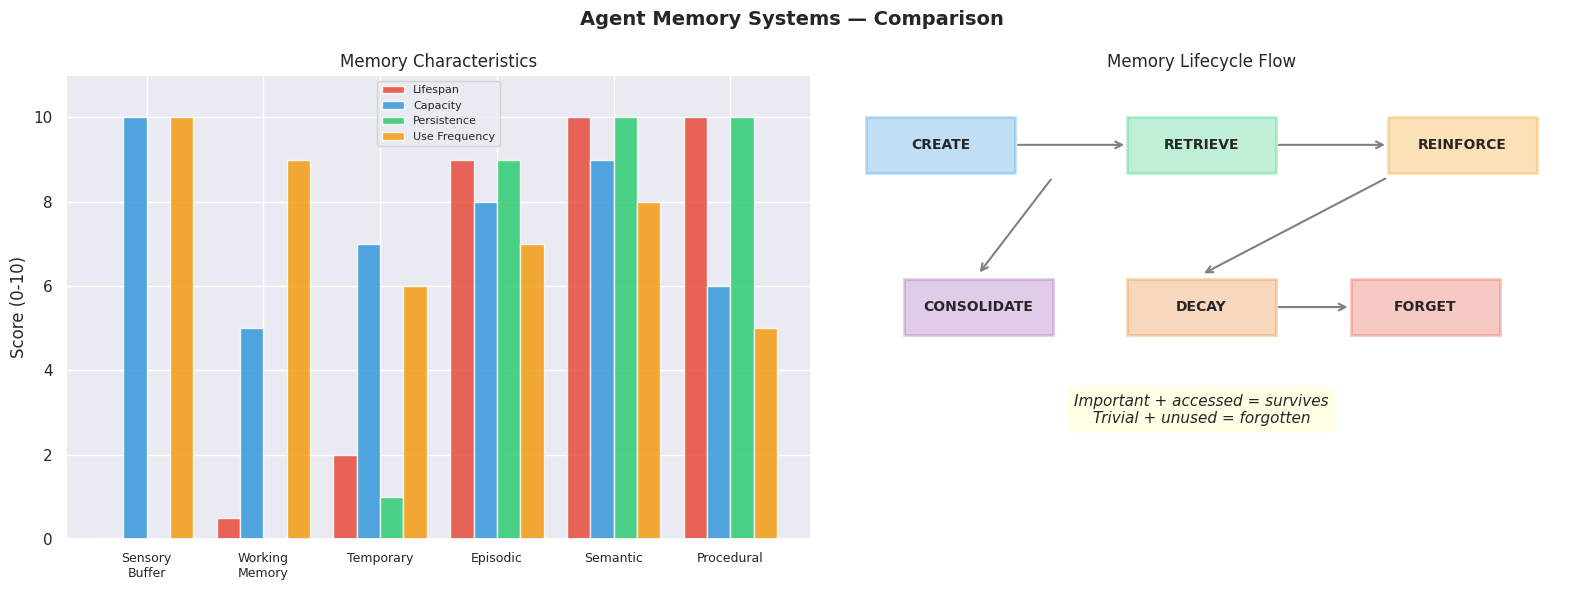

✅ Saved: memory_systems_comparison.png


In [16]:
# ── 9. Memory Comparison Dashboard ──────────────────────────────────────────

memory_types = {
    'Sensory\nBuffer': {'lifespan': 0.01, 'capacity': 10, 'persistence': 0, 'use_frequency': 10},
    'Working\nMemory': {'lifespan': 0.5, 'capacity': 5, 'persistence': 0, 'use_frequency': 9},
    'Temporary': {'lifespan': 2, 'capacity': 7, 'persistence': 1, 'use_frequency': 6},
    'Episodic': {'lifespan': 9, 'capacity': 8, 'persistence': 9, 'use_frequency': 7},
    'Semantic': {'lifespan': 10, 'capacity': 9, 'persistence': 10, 'use_frequency': 8},
    'Procedural': {'lifespan': 10, 'capacity': 6, 'persistence': 10, 'use_frequency': 5},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Agent Memory Systems — Comparison', fontsize=14, fontweight='bold')

# Grouped bar chart
ax1 = axes[0]
types = list(memory_types.keys())
dims = ['lifespan', 'capacity', 'persistence', 'use_frequency']
x = np.arange(len(types))
width = 0.2
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, dim in enumerate(dims):
    vals = [memory_types[t][dim] for t in types]
    ax1.bar(x + i * width, vals, width, label=dim.replace('_', ' ').title(), color=colors[i], alpha=0.85)
ax1.set_xticks(x + 1.5 * width)
ax1.set_xticklabels(types, fontsize=9)
ax1.set_ylabel('Score (0-10)')
ax1.set_title('Memory Characteristics')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 11)

# Lifecycle flow
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title('Memory Lifecycle Flow')
ax2.axis('off')

steps = [
    (1.5, 8.5, 'CREATE', '#3498db'),
    (5, 8.5, 'RETRIEVE', '#2ecc71'),
    (8.5, 8.5, 'REINFORCE', '#f39c12'),
    (2, 5, 'CONSOLIDATE', '#9b59b6'),
    (5, 5, 'DECAY', '#e67e22'),
    (8, 5, 'FORGET', '#e74c3c'),
]

for x_pos, y_pos, label, color in steps:
    ax2.add_patch(plt.Rectangle((x_pos - 1, y_pos - 0.6), 2, 1.2,
                                facecolor=color, alpha=0.3, edgecolor=color, linewidth=2,
                                zorder=2))
    ax2.text(x_pos, y_pos, label, ha='center', va='center', fontweight='bold', fontsize=10, zorder=3)

# Arrows
arrow_props = dict(arrowstyle='->', color='gray', lw=1.5)
ax2.annotate('', xy=(4, 8.5), xytext=(2.5, 8.5), arrowprops=arrow_props)
ax2.annotate('', xy=(7.5, 8.5), xytext=(6, 8.5), arrowprops=arrow_props)
ax2.annotate('', xy=(2, 5.7), xytext=(3, 7.8), arrowprops=arrow_props)
ax2.annotate('', xy=(5, 5.7), xytext=(7.5, 7.8), arrowprops=arrow_props)
ax2.annotate('', xy=(7, 5), xytext=(6, 5), arrowprops=arrow_props)

ax2.text(5, 2.5, 'Important + accessed = survives\nTrivial + unused = forgotten',
         ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('memory_systems_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: memory_systems_comparison.png')

---
# Summary

| Memory Type | What It Stores | Lifespan | Agent Implementation |
|-------------|---------------|----------|---------------------|
| **Sensory Buffer** | Raw tokens currently in context | One LLM call | Context window (auto) |
| **Working Memory** | Current task reasoning steps | One graph run | `Annotated[list, operator.add]` scratchpad |
| **Episodic** | Past interactions as events | Permanent | List of Episode objects + similarity retrieval |
| **Semantic** | Facts, preferences, knowledge | Permanent | Key-value fact store + auto-extraction |
| **Procedural** | How to do things (skills) | Permanent | Procedure objects with success tracking |
| **Temporary** | Task-scoped, time-limited state | TTL-based | Dict with expiry timestamps |
| **Permanent** | Anything critical to persist | Forever | File/DB-backed store |

### Key Insights
> A real agent needs **all** these memory types working together.  
> The **Unified Memory Agent** (Cell 7) shows how to wire them into a single LangGraph pipeline:  
> **Retrieve** from long-term → **Reason** with working memory → **Respond** → **Update** all stores.